Python notebook to calculate various statistics between two annotations.

## Data and Libraries

In [1]:
from dataset_processing import cwed4eta_process_json_file, convert_to_token_spans, CLIRENER_LABELS_V1
import numpy as np
import krippendorff
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from os import listdir
from pathlib import Path
import itertools

from collections import defaultdict, Counter

### Helper Functions

In [37]:
def process_directory_of_json_files(directory_path, annotator_importance_list):
    json_files = [file for file in listdir(directory_path) if file.endswith("json")]
    
    compound_json = []
    
    for file in json_files:
        compound_json.extend(cwed4eta_process_json_file(str(Path(directory_path + file)), annotator_importance_list))
        
    return compound_json

def generate_consistent_label_map(entity_types):
    """
    Generates a consistent BIO label map from a set of raw entity types.
    Ensures 'O' is included and indices are deterministic (sorted).
    """
    # 1. Always start with 'O'
    bio_labels = ["O"]
    
    # 2. Create B- and I- tags for every entity type
    sorted_types = sorted(list(entity_types))
    for label in sorted_types:
        bio_labels.append(f"B-{label}")
        bio_labels.append(f"I-{label}")
        
    # 3. Create the dictionary: {'O': 0, 'B-Asset': 1, ...}
    # We sort the final list to ensure 'O' and the rest are in a predictable order
    # (Optional: You can enforce 'O' to be 0 specifically, but alphabetical sort is also fine)
    bio_labels.sort()
    
    return {label: i for i, label in enumerate(bio_labels)}

# --- 2. Helper: Spans to BIO (Required for the main function) ---
def spans_to_bio_tags(token_list, ner_spans):
    
    tags = ["O"] * len(token_list)
    if len(ner_spans[0]) == 3:
        for start, end, label in ner_spans:
            # Construct the expected tags
            b_tag = f"B-{label}"
            i_tag = f"I-{label}"
            
            # Apply B tag
            tags[start] = b_tag
            
            # Apply I tags
            if end > start:
                for i in range(start + 1, end + 1):
                    tags[i] = i_tag
    elif len(ner_spans[0]) == 4:
        for start, end, label, _ in ner_spans:
            # Construct the expected tags
            b_tag = f"B-{label}"
            i_tag = f"I-{label}"
            
            # Apply B tag
            tags[start] = b_tag
            
            # Apply I tags
            if end > start:
                for i in range(start + 1, end + 1):
                    tags[i] = i_tag
    return tags

# --- 3. Main Calculation Function ---
def calculate_ner_agreement(data_coder_1, data_coder_2, label_map=None):
    """
    Calculates Alpha and Confusion Matrix using a consistent label map.
    
    Args:
        data_coder_1: List of dicts from Coder 1
        data_coder_2: List of dicts from Coder 2
        label_map: (Optional) Precomputed dict {'B-Person': 1, ...}. 
                   If None, generates it from CLIRENER_LABELS_V1.
    """
    
    # If no map provided, generate the default one
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    # Dictionary lookup for faster access by ID
    dict_c1 = {d['id']: d for d in data_coder_1}
    dict_c2 = {d['id']: d for d in data_coder_2}
    
    common_ids = set(dict_c1.keys()).intersection(set(dict_c2.keys()))
    
    if not common_ids:
        print("No matching IDs found between datasets.")
        return None, 0, None, label_map

    all_tags_1 = []
    all_tags_2 = []

    # Iterate through matched documents
    for doc_id in sorted(common_ids):
        doc1 = dict_c1[doc_id]
        doc2 = dict_c2[doc_id]
        
        # Sanity check: Token length
        tokens = doc1['tokenized_text']
        if len(tokens) != len(doc2['tokenized_text']):
            print(f"Warning: Token mismatch for ID {doc_id}. Skipping.")
            continue
            
        # Convert spans to BIO tags
        tags1 = spans_to_bio_tags(tokens, doc1['ner'])
        tags2 = spans_to_bio_tags(tokens, doc2['ner'])
        
        all_tags_1.extend(tags1)
        all_tags_2.extend(tags2)

    # --- Encode Tags to Integers ---
    encoded_row_1 = []
    encoded_row_2 = []
    
    try:
        encoded_row_1 = [label_map[t] for t in all_tags_1]
        encoded_row_2 = [label_map[t] for t in all_tags_2]
    except KeyError as e:
        print(f"CRITICAL ERROR: Found a tag in data that is not in CLIRENER_LABELS_V1: {e}")
        print("Please update your constant set or fix the data.")
        return None, 0, None, label_map

    # --- Calculate Krippendorff's Alpha ---
    reliability_data = [encoded_row_1, encoded_row_2]
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement="nominal"
    )

    # --- Calculate Confusion Matrix ---
    # IMPORTANT: We pass the full list of label_map values (0 to N) to 'labels'.
    # This ensures the matrix is always the full size (e.g. 57x57) even if 
    # some tags (like B-Body Part) don't appear in this specific dataset.
    all_possible_indices = sorted(list(label_map.values()))
    
    cm = confusion_matrix(
        encoded_row_1, 
        encoded_row_2, 
        labels=all_possible_indices
    )
    
    return alpha, len(all_tags_1), cm, label_map


def print_top_confusions(conf_mat, label_map, top_n=10):
    index_to_label = {v: k for k, v in label_map.items()}
    confusions = []

    rows, cols = conf_mat.shape
    for r in range(rows):
        for c in range(cols):
            if r != c: # Skip correct matches
                count = conf_mat[r, c]
                if count > 0:
                    confusions.append((count, index_to_label[r], index_to_label[c]))

    # Sort by count descending
    confusions.sort(key=lambda x: x[0], reverse=True)

    print(f"{'Count':<10} | {'Coder 1 (Row)':<30} -> {'Coder 2 (Col)':<30}")
    print("-" * 75)
    for count, l1, l2 in confusions[:top_n]:
        print(f"{count:<10} | {l1:<30} -> {l2:<30}")


def plot_ner_confusion_matrix(conf_mat, label_map, hide_diagonal=True):
    """
    Plots a large confusion matrix for NER.
    
    Args:
        conf_mat: The square matrix (numpy array) returned by confusion_matrix()
        label_map: The dictionary {'Label': index} used for encoding
        hide_diagonal: If True, sets diagonal to 0 to highlight ERRORS only.
    """
    
    # 1. Get labels in the correct sorted order (0, 1, 2...)
    # We invert the dictionary: {0: 'B-Asset', 1: 'B-Body...', ...}
    index_to_label = {v: k for k, v in label_map.items()}
    labels = [index_to_label[i] for i in range(len(index_to_label))]

    # 2. Prepare data for plotting
    plot_data = conf_mat.copy()
    
    # (Optional) Zero out the diagonal to make the ERRORS pop out.
    # Otherwise, the massive agreement on 'O' tag washes out the colors.
    if hide_diagonal:
        np.fill_diagonal(plot_data, 0)

    # 3. Create the Plot
    # Size must be large (e.g., 24x24) to accommodate 55+ labels
    plt.figure(figsize=(24, 24))
    
    sns.heatmap(
        plot_data, 
        annot=True,           # Show numbers in cells
        fmt="d",              # Format as integer (d)
        cmap="Reds",          # Color scheme (Darker red = more confusion)
        xticklabels=labels, 
        yticklabels=labels,
        cbar_kws={'label': 'Count of Disagreements'}
    )

    plt.title("NER Confusion Matrix (Coder 1 vs Coder 2)", fontsize=20)
    plt.ylabel("Coder 1 (True/Reference)", fontsize=15)
    plt.xlabel("Coder 2 (Predicted)", fontsize=15)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()


def calculate_ner_agreement_generalized(list_of_coder_data, label_map=None):
    """
    Calculates Alpha and Aggregated Confusion Matrix for N annotators.
    
    Args:
        list_of_coder_data: A list containing datasets for each coder. 
                            Example: [data_coder_1, data_coder_2, data_coder_3]
        label_map: (Optional) Precomputed dict. If None, generates from CLIRENER_LABELS_V1.
    """
    
    num_coders = len(list_of_coder_data)
    if num_coders < 2:
        print("Error: Need at least 2 coders to calculate agreement.")
        return None, 0, None, label_map

    # 1. Generate Label Map if missing
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    # 2. Index all datasets by ID for fast lookup
    # coder_dicts is a list of dictionaries: [{id: doc}, {id: doc}, ...]
    coder_dicts = [{d['id']: d for d in dataset} for dataset in list_of_coder_data]

    # 3. Find intersection of IDs across ALL coders
    # Start with IDs from the first coder
    common_ids = set(coder_dicts[0].keys())
    # Intersect with every other coder
    for c_dict in coder_dicts[1:]:
        common_ids.intersection_update(c_dict.keys())
    
    if not common_ids:
        print("No common document IDs found across all provided datasets.")
        return None, 0, None, label_map

    print(f"Calculating agreement on {len(common_ids)} common documents among {num_coders} coders.")

    # 4. Prepare data containers (List of lists)
    # encoded_rows[0] will hold all integer tags for Coder 1, etc.
    encoded_rows = [[] for _ in range(num_coders)]
    total_tokens = 0

    # 5. Iterate through matched documents
    for doc_id in sorted(common_ids):
        
        # A. Sanity Check: Token lengths must match across ALL coders
        token_counts = [len(c_dict[doc_id]['tokenized_text']) for c_dict in coder_dicts]
        if len(set(token_counts)) != 1:
            print(f"Warning: Token length mismatch for ID {doc_id} among coders {token_counts}. Skipping.")
            continue
        
        # Use tokens from the first coder (since we verified they are all same length)
        tokens = coder_dicts[0][doc_id]['tokenized_text']
        total_tokens += len(tokens)

        # B. Convert spans to BIO tags for each coder
        for i in range(num_coders):
            doc_data = coder_dicts[i][doc_id]
            
            try:
                tags = spans_to_bio_tags(tokens, doc_data['ner'])
                encoded = [label_map[t] for t in tags]
                encoded_rows[i].extend(encoded)
            except KeyError as e:
                print(f"CRITICAL ERROR: Tag not in map: {e}")
                return None, 0, None, label_map

    # --- 6. Calculate Krippendorff's Alpha ---
    # input must be shape (n_coders, n_items)
    alpha = krippendorff.alpha(
        reliability_data=encoded_rows,
        level_of_measurement="nominal"
    )

    # --- 7. Calculate Aggregated Confusion Matrix ---
    # We sum the confusion matrices of all unique pairs.
    all_possible_indices = sorted(list(label_map.values()))
    num_classes = len(all_possible_indices)
    
    # Initialize an empty square matrix
    aggregated_cm = np.zeros((num_classes, num_classes), dtype=int)
    
    # Generate all unique pairs of coders (e.g., (0,1), (0,2), (1,2))
    pairs = list(itertools.combinations(range(num_coders), 2))
    
    for coder_a_idx, coder_b_idx in pairs:
        pair_cm = confusion_matrix(
            encoded_rows[coder_a_idx], 
            encoded_rows[coder_b_idx], 
            labels=all_possible_indices
        )
        aggregated_cm += pair_cm

    return alpha, total_tokens, aggregated_cm, label_map

# 
def calculate_ner_agreement_partial(list_of_coder_data, min_overlap=2, label_map=None):
    """
    Calculates Alpha and Aggregated Confusion Matrix for documents annotated by 
    AT LEAST `min_overlap` coders. Handles missing data using np.nan.
    
    Args:
        list_of_coder_data: List of lists (datasets).
        min_overlap: Minimum number of annotators required per document to include it.
        label_map: (Optional) Label dictionary.
    """
    
    num_coders = len(list_of_coder_data)
    if num_coders < min_overlap:
        print(f"Error: Not enough coders provided ({num_coders}) to satisfy min_overlap ({min_overlap}).")
        return None, 0, None, label_map

    # 1. Generate Label Map
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    # 2. Index datasets
    coder_dicts = [{d['id']: d for d in dataset} for dataset in list_of_coder_data]

    # 3. Find Union of all IDs
    all_ids = set()
    for c_dict in coder_dicts:
        all_ids.update(c_dict.keys())
        
    # 4. Filter IDs by "At Least N" overlap
    valid_ids = []
    for doc_id in all_ids:
        # Count how many coders have this doc_id
        count = sum(1 for c_dict in coder_dicts if doc_id in c_dict)
        if count >= min_overlap:
            valid_ids.append(doc_id)
            
    if not valid_ids:
        print(f"No documents found with at least {min_overlap} annotators.")
        return None, 0, None, label_map
    
    # Sort for deterministic processing order
    valid_ids.sort()
    
    print(f"Processing {len(valid_ids)} documents (filtered for >={min_overlap} overlap).")

    # 5. Build Reliability Matrix (Rows=Coders, Cols=Tokens) with np.nan
    # We build lists first, then convert to numpy array
    encoded_rows = [[] for _ in range(num_coders)]
    total_tokens_processed = 0

    for doc_id in valid_ids:
        # A. Find a "Reference" coder (anyone who annotated this doc) to get token length
        # We know at least `min_overlap` coders have it.
        reference_coder_idx = next(i for i, d in enumerate(coder_dicts) if doc_id in d)
        tokens = coder_dicts[reference_coder_idx][doc_id]['tokenized_text']
        doc_len = len(tokens)
        total_tokens_processed += doc_len

        # B. Process each coder
        for i in range(num_coders):
            c_dict = coder_dicts[i]
            
            if doc_id in c_dict:
                # Validate token length matches reference
                current_tokens = c_dict[doc_id]['tokenized_text']
                if len(current_tokens) != doc_len:
                    print(f"Warning: Token mismatch ID {doc_id} (Coder {i}). Padding with NaN.")
                    encoded_rows[i].extend([np.nan] * doc_len)
                    continue

                try:
                    # Convert spans to BIO tags -> Integers
                    tags = spans_to_bio_tags(current_tokens, c_dict[doc_id]['ner'])
                    encoded_vals = [label_map[t] for t in tags]
                    encoded_rows[i].extend(encoded_vals)
                except KeyError as e:
                    print(f"CRITICAL ERROR: Tag not in map: {e}")
                    return None, 0, None, label_map
            else:
                # This coder did NOT annotate this document -> Pad with NaNs
                encoded_rows[i].extend([np.nan] * doc_len)

    # Convert to numpy array for Krippendorff
    reliability_data = np.array(encoded_rows)

    # --- 6. Calculate Krippendorff's Alpha ---
    # Krippendorff handles np.nan automatically
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement="nominal"
    )

    # --- 7. Calculate Aggregated Confusion Matrix ---
    # We must explicitly handle NaNs here (only compare where BOTH exist)
    all_possible_indices = sorted(list(label_map.values()))
    num_classes = len(all_possible_indices)
    aggregated_cm = np.zeros((num_classes, num_classes), dtype=int)
    
    pairs = list(itertools.combinations(range(num_coders), 2))
    
    for c1_idx, c2_idx in pairs:
        row_1 = reliability_data[c1_idx]
        row_2 = reliability_data[c2_idx]
        
        # Create a mask where BOTH are NOT NaN
        # (i.e., tokens where both Coder A and Coder B provided an annotation)
        valid_mask = (~np.isnan(row_1)) & (~np.isnan(row_2))
        
        if np.any(valid_mask):
            # Extract valid comparisons and convert to int
            y_true = row_1[valid_mask].astype(int)
            y_pred = row_2[valid_mask].astype(int)
            
            pair_cm = confusion_matrix(
                y_true, 
                y_pred, 
                labels=all_possible_indices
            )
            aggregated_cm += pair_cm

    return alpha, total_tokens_processed, aggregated_cm, label_map

### Data Loading

In [3]:
ANNOTATOR_DIR = "/home/p0l3/RAD/DROP/CLIRENER/ANNOTATORS/"
"/home/p0l3/RAD/DROP/CLIRENER/ANNOTATORS/5/"
data_0 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "0/" + "OG.json"))
data_1 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "1/" + "G3_12126.json", [5]))
data_2 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "2/" + "G4_12126.json", [1, 6]))  
data_3 = None
data_4 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "4/" + "G2_7126.json", [8])) 
data_5 = convert_to_token_spans(process_directory_of_json_files("RESULTS/ANNOTATORS/5/", [9]))
data_6 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "6/" + "G1_12126.json", [13])) 
data_7 = None
data_8 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "8/" + "G6_7126.json", [12]))
data_9 = None
data_10 = None
data_11 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "11/" + "G5_12126.json", [1, 14]))
data_12 = None

##
# A0 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "0/" + "OG.json")) 
# A1 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "1/" + "G3_12126.json", [5]))
# A2 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "2/" + "G4_12126.json", [1, 6])) 
# A4 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "4/" + "G2_7126.json", [8])) 
# A5 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "5/" + "G6.json", [9])) 
# A6 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "6/" + "G1_9126.json", [13])) 
# A8 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "8/" + "G6_7126.json", [12]))
# A11 - convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "11/" + "G5_12126.json", [1, 14]))


# data_1 = convert_to_token_spans(cwed4eta_process_json_file("DATA/project-30-at-2025-11-14-12-19-2a7464a5.json"))

# # data_2 = convert_to_token_spans(cwed4eta_process_json_file("RESULTS/ANNOTATORS/5/part3_G6.json", [9]))
# ## OR
# data_2 = convert_to_token_spans(process_directory_of_json_files("RESULTS/ANNOTATORS/5/", [9]))

## Krippendorff for Two

Alpha: 0.6328
Mapping size: 57 tags


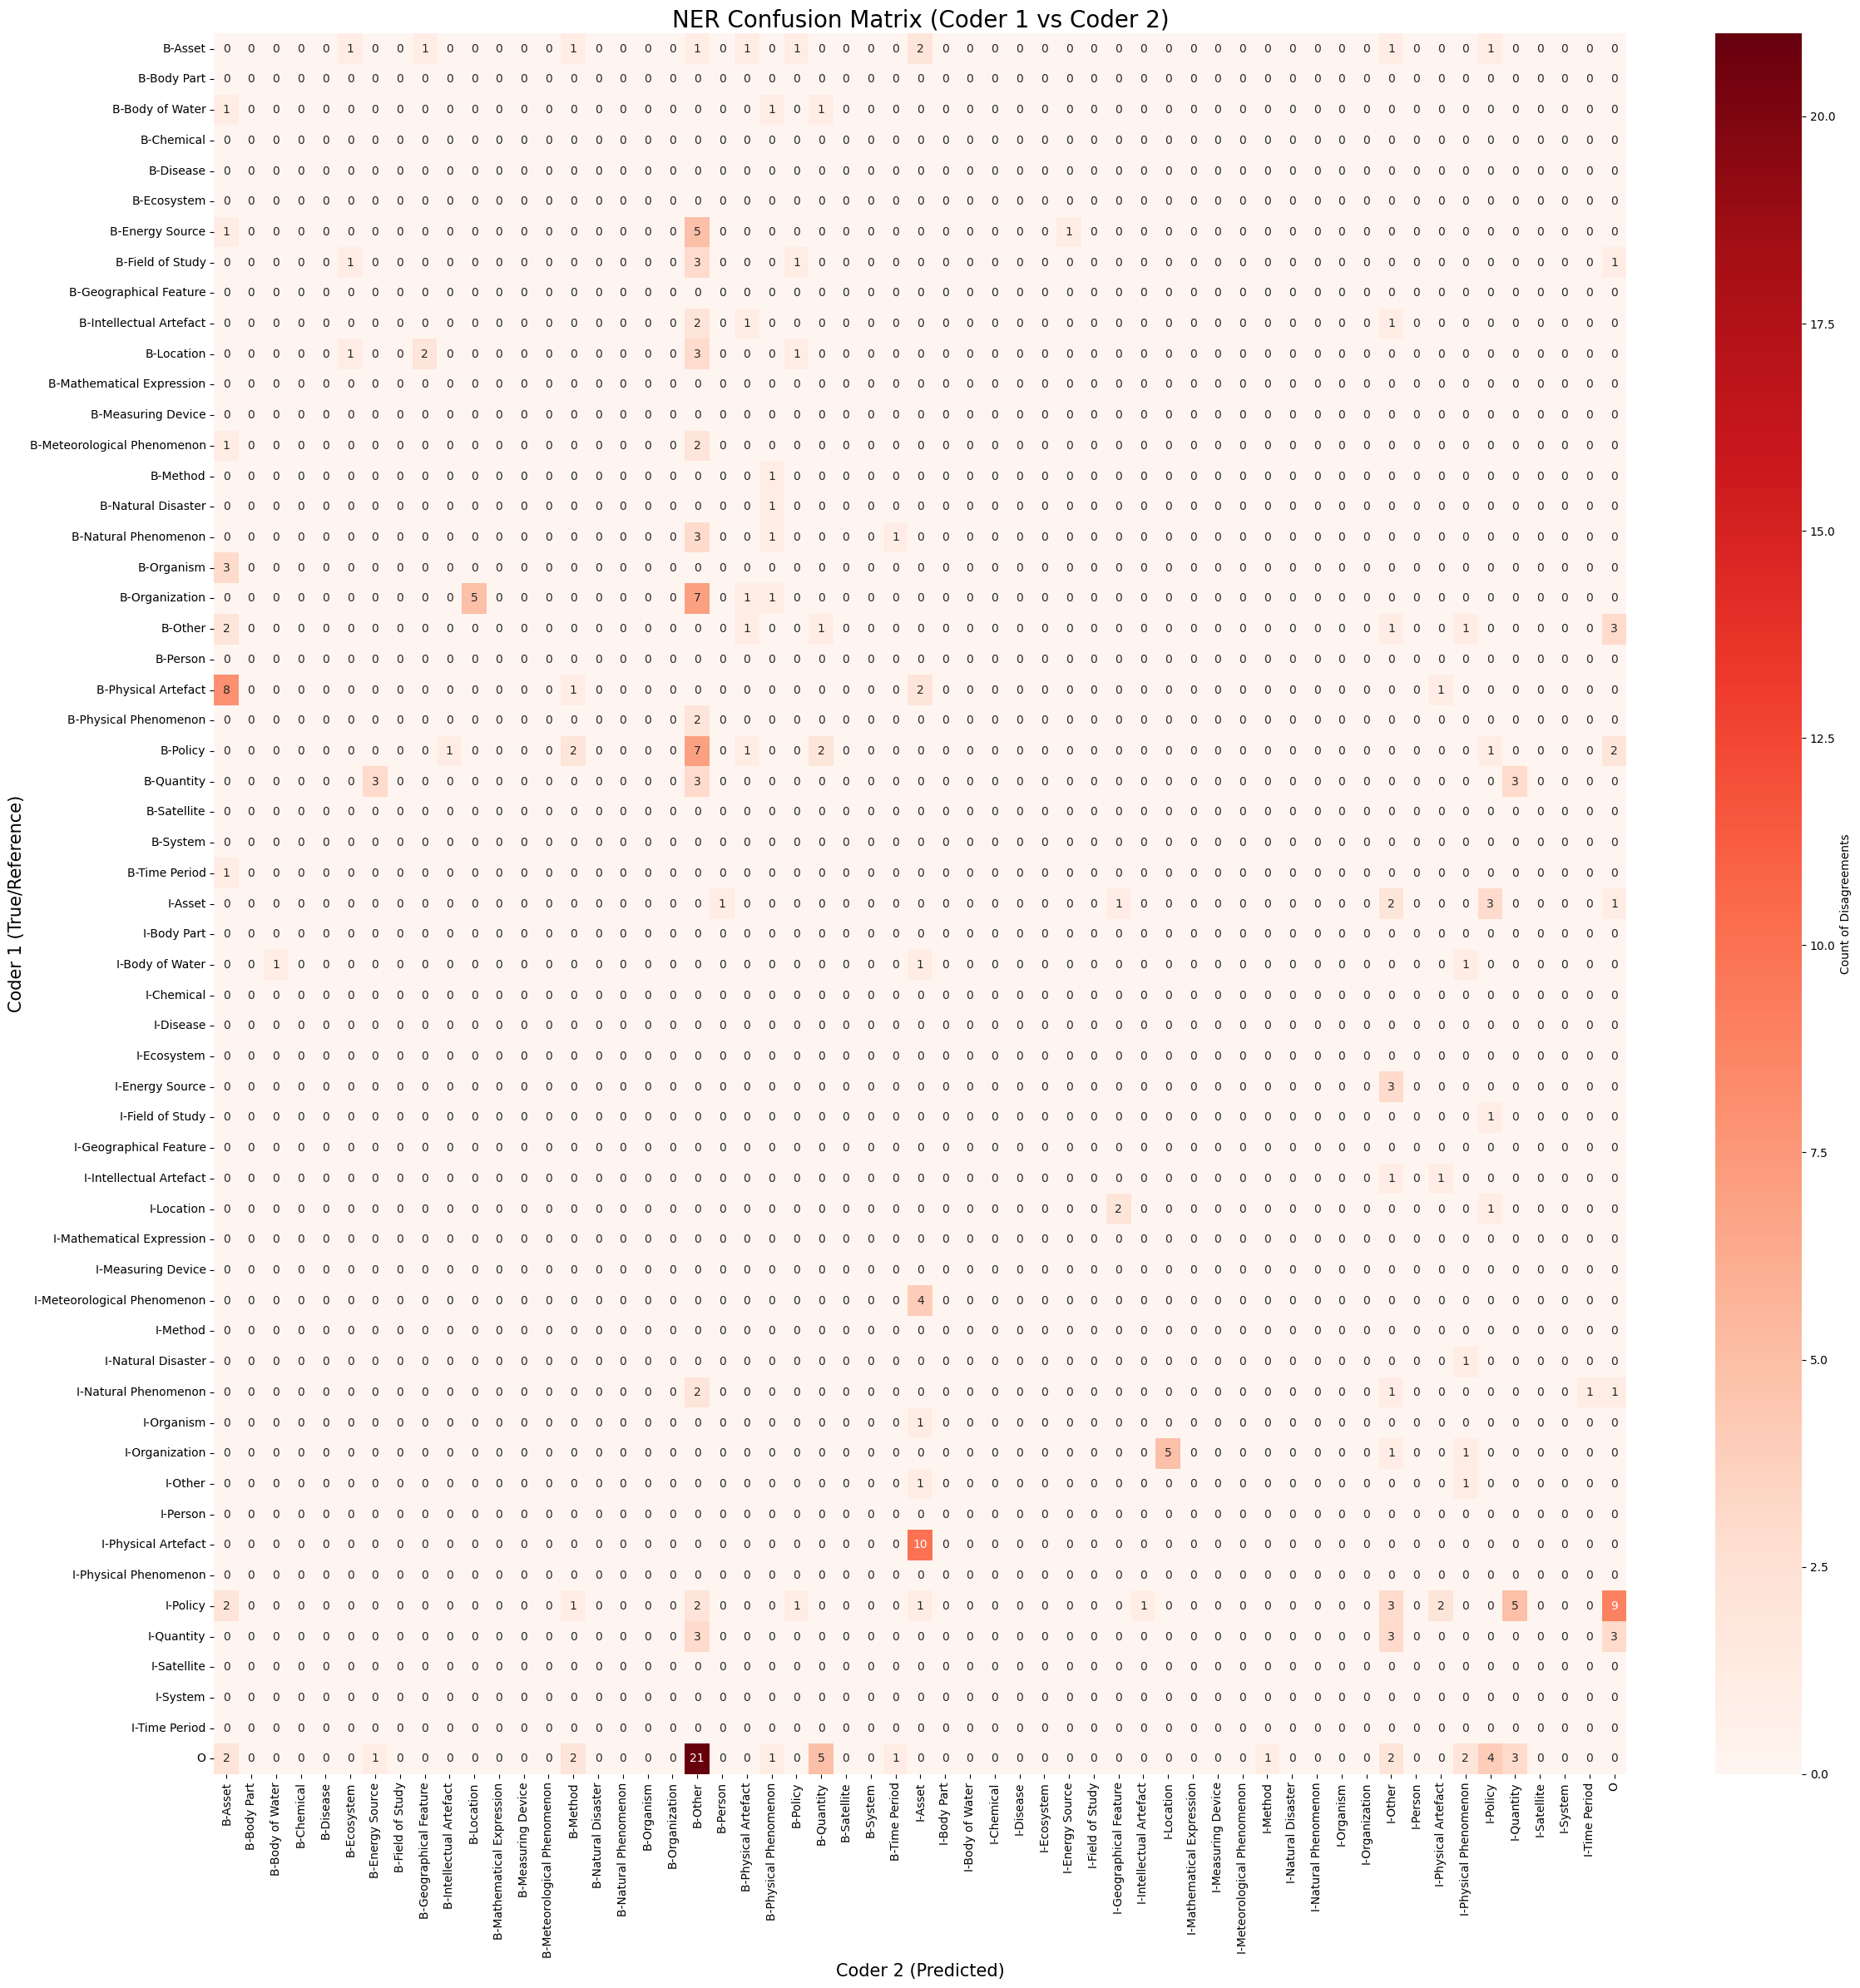

In [54]:
# 1. Run calculation
alpha, count, cm, mapping = calculate_ner_agreement(data_5, data_6)

# 2. Print results
print(f"Alpha: {alpha:.4f}")
print(f"Mapping size: {len(mapping)} tags")

# 3. Plot (using the plot function provided previously)
if cm is not None:
    plot_ner_confusion_matrix(cm, mapping, hide_diagonal=True)

In [55]:
print_top_confusions(cm, mapping)

Count      | Coder 1 (Row)                  -> Coder 2 (Col)                 
---------------------------------------------------------------------------
21         | O                              -> B-Other                       
10         | I-Physical Artefact            -> I-Asset                       
9          | I-Policy                       -> O                             
8          | B-Physical Artefact            -> B-Asset                       
7          | B-Organization                 -> B-Other                       
7          | B-Policy                       -> B-Other                       
5          | B-Energy Source                -> B-Other                       
5          | B-Organization                 -> B-Location                    
5          | I-Organization                 -> I-Location                    
5          | I-Policy                       -> I-Quantity                    


## Krippendorff for Many

In [61]:
all_coders = [
    # data_0,
    # data_2,
    # data_4,
    data_5,
    data_6,
    data_8,
    # data_11
    ]

# alpha, count, cm, mapping = calculate_ner_agreement_generalized(all_coders)
alpha, count, cm, mapping =  calculate_ner_agreement_partial(all_coders)

Processing 77 documents (filtered for >=2 overlap).


In [62]:
cm

array([[  29,    0,    0, ...,    0,    0,    0],
       [   0,    2,    0, ...,    0,    0,    0],
       [   1,    0,   28, ...,    0,    0,    0],
       ...,
       [   0,    0,    0, ...,    6,    0,    0],
       [   0,    0,    0, ...,    0,   16,    2],
       [   2,    0,    0, ...,    1,    0, 2466]])

Global Alpha: 0.6909


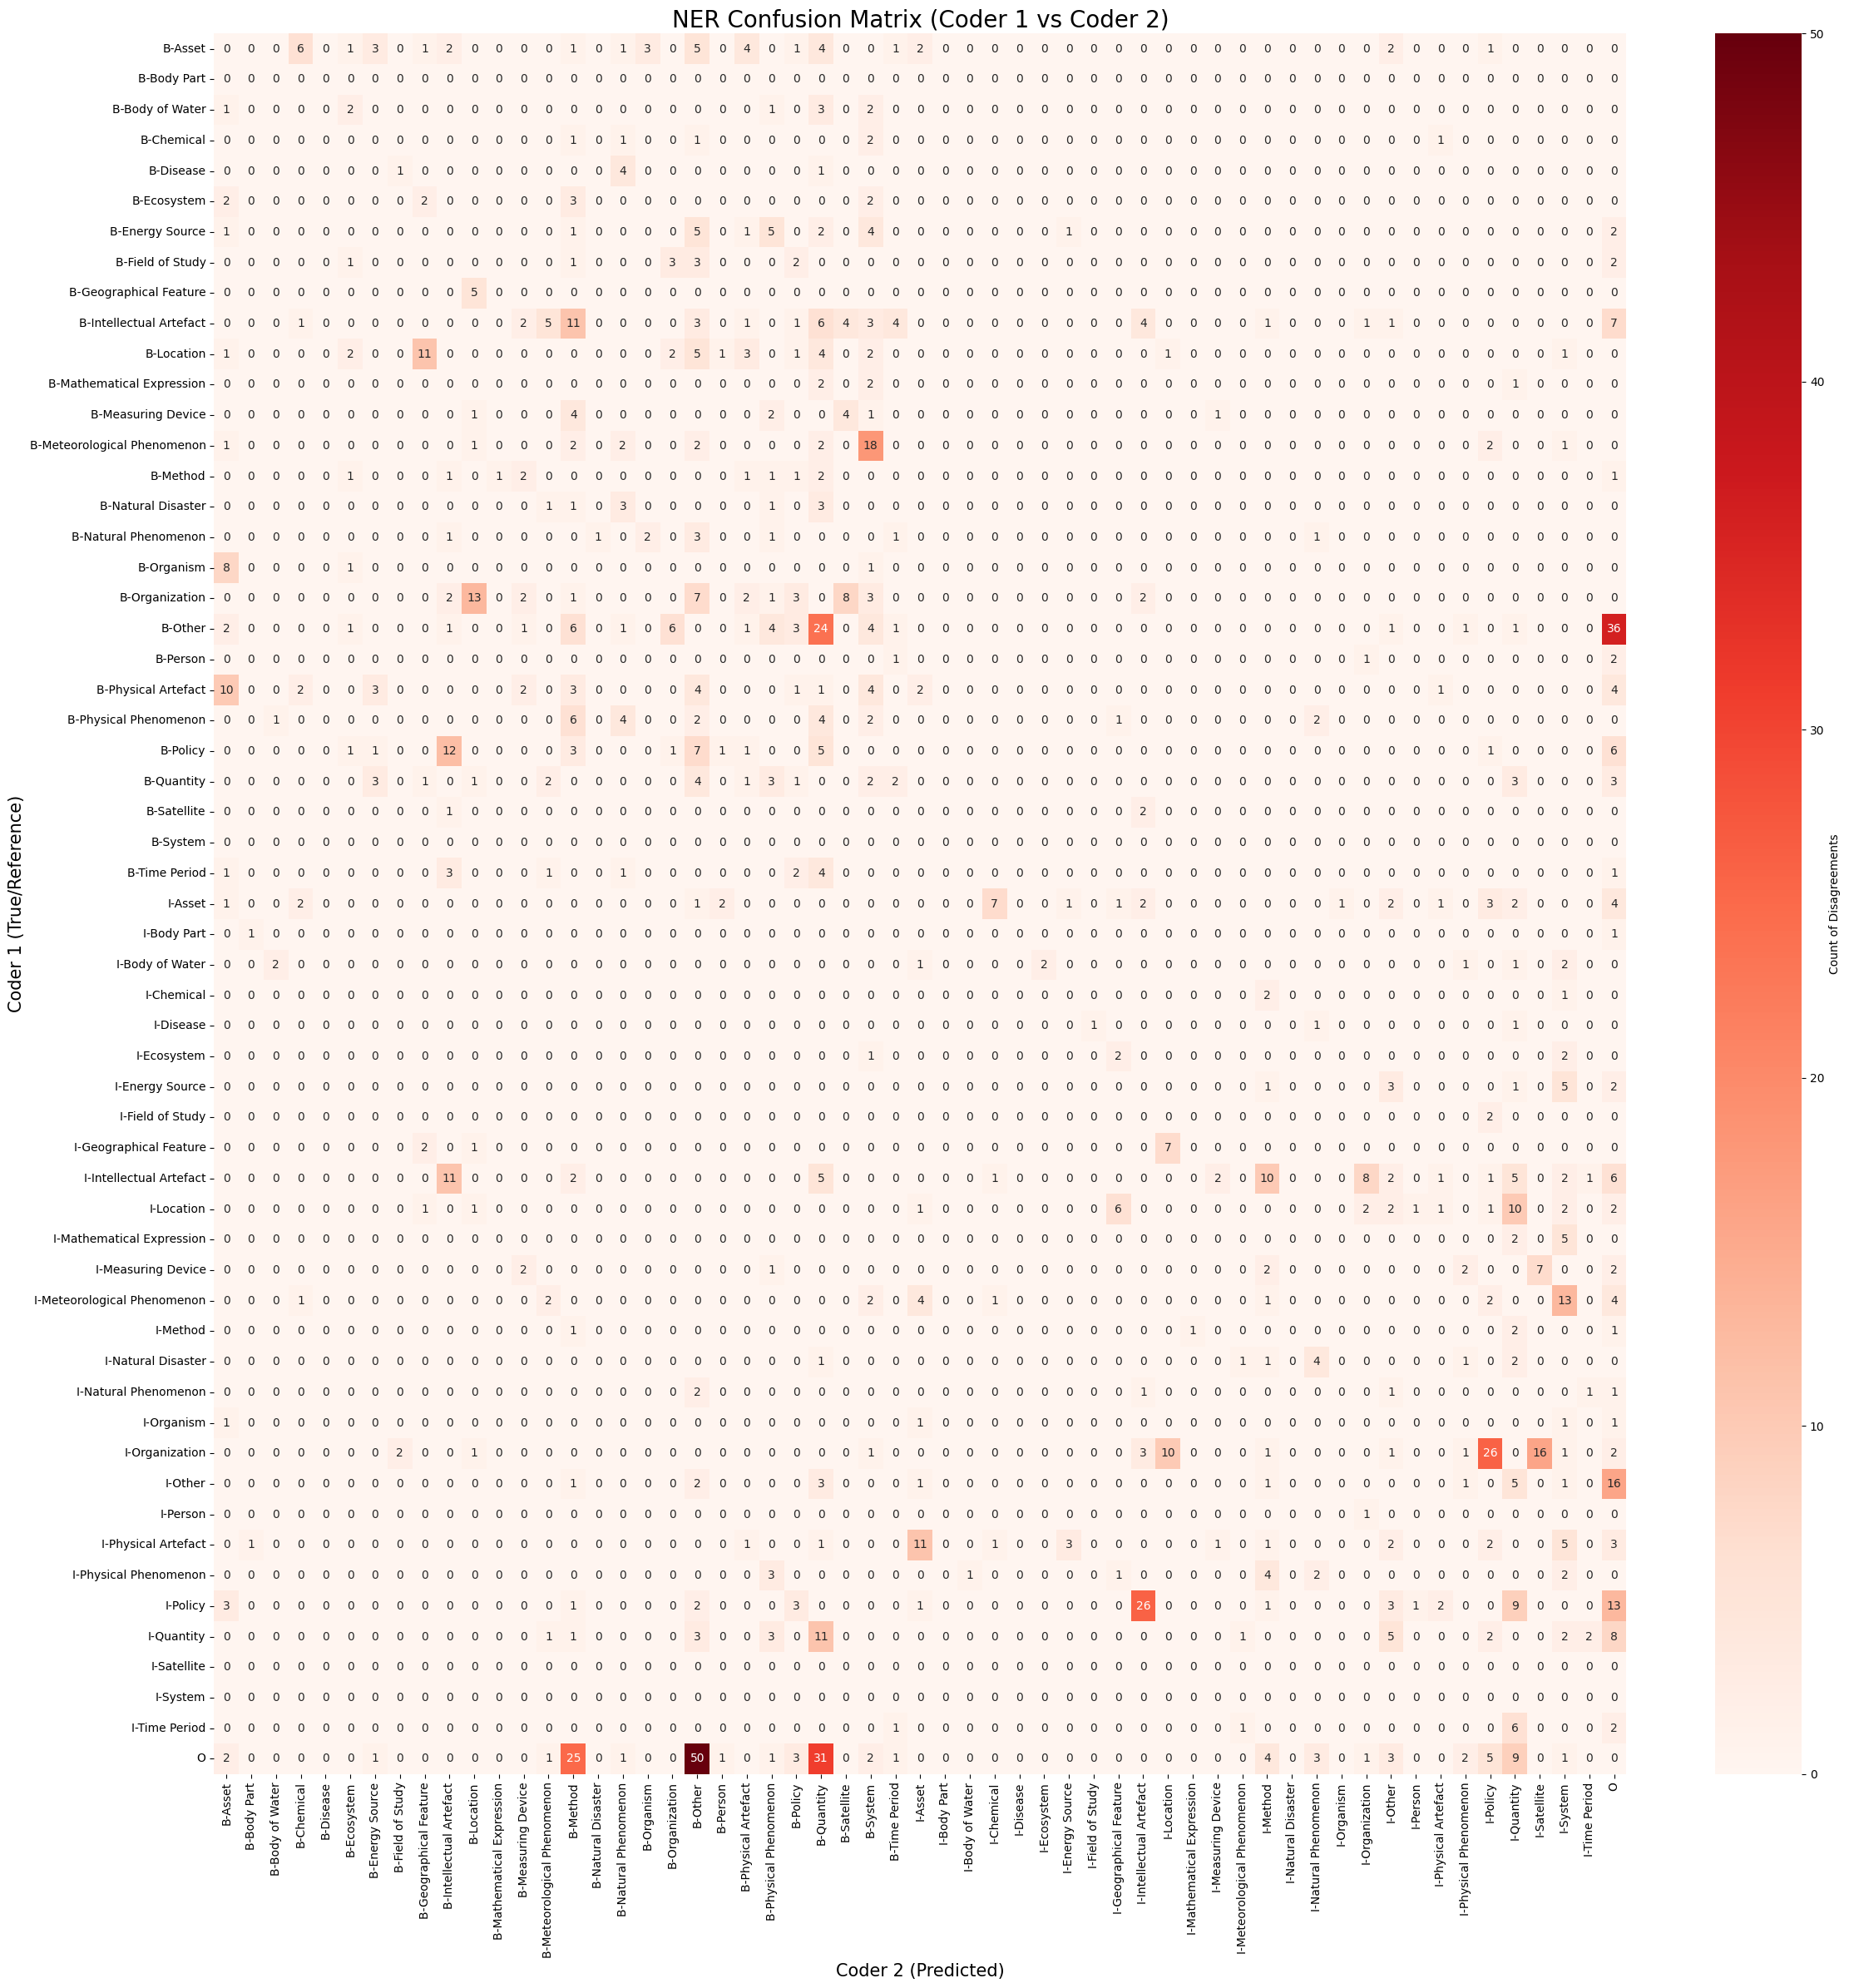

In [63]:
print(f"Global Alpha: {alpha:.4f}")
plot_ner_confusion_matrix(cm, mapping)

## Final NER dataset

In [27]:
import uuid
import numpy as np
import krippendorff
from collections import defaultdict
from dataset_processing import CLIRENER_LABELS_V1
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings 

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")


def analyze_consensus_statistics(consensus_data, plot_graphs=True):
    """
    Analyzes the consensus dataset and prints/plots statistics.
    
    Args:
        consensus_data: List of dicts produced by generate_consensus_dataset
        plot_graphs: Boolean, whether to show matplotlib plots
    """
    
    # --- Containers for aggregation ---
    all_alphas = []
    
    # Tie tracking
    total_ties = 0
    tie_winning_labels = []
    
    # Entity tracking
    all_entity_labels = []
    doc_entity_counts = []
    
    # Filtering stats
    docs_with_2plus_raters = 0
    high_quality_docs = 0 # > 0.66 alpha
    
    # Sentence length tracking
    token_lengths = []

    print("="*60)
    print("CONSENSUS DATASET STATISTICS")
    print("="*60)

    # --- 1. Iterate and Collect Data ---
    for doc in consensus_data:
        # Alpha
        alpha = doc.get('alpha')
        num_raters = doc.get('num_raters', 0)
        
        # Valid Alpha Logic (Exclude None and NaN)
        if alpha is not None and not np.isnan(alpha):
            all_alphas.append(alpha)
            
            # Check criteria: >= 2 raters AND Alpha > 0.66
            if num_raters >= 2:
                docs_with_2plus_raters += 1
                if alpha > 0.66:
                    high_quality_docs += 1
        
        # Entities & Ties
        doc_ent_count = 0
        tokens = doc.get('tokenized_text', [])
        token_lengths.append(len(tokens))
        
        for start, end, label, is_tie in doc['ner']:
            all_entity_labels.append(label)
            doc_ent_count += 1
            
            if is_tie:
                total_ties += 1
                tie_winning_labels.append(label)
        
        doc_entity_counts.append(doc_ent_count)

    # --- 2. Tie Related Statistics ---
    print(f"\n[1] TIE ANALYSIS")
    print(f"Total Confirmed Ties: {total_ties}")
    
    if tie_winning_labels:
        tie_counts = Counter(tie_winning_labels)
        most_common_tie = tie_counts.most_common(1)[0]
        print(f"Most Frequent Tie Winner: '{most_common_tie[0]}' ({most_common_tie[1]} times)")
        print("Tie Winners Distribution:")
        for label, count in tie_counts.most_common(5):
            print(f"  - {label}: {count}")
    else:
        print("No ties found.")

    # --- 3. Krippendorff's Alpha Statistics ---
    print(f"\n[2] AGREEMENT STATISTICS (Krippendorff's Alpha)")
    
    if all_alphas:
        avg_alpha = np.mean(all_alphas)
        median_alpha = np.median(all_alphas)
        print(f"Overall Average Alpha: {avg_alpha:.4f}")
        print(f"Median Alpha:        {median_alpha:.4f}")
        print(f"Min: {min(all_alphas):.4f} | Max: {max(all_alphas):.4f}")
    else:
        print("No valid alpha scores found.")

    # --- 4. General Quality Filter ---
    print(f"\n[3] DATASET QUALITY FILTER")
    print(f"Total Sentences (with valid alpha & >=2 raters): {docs_with_2plus_raters}")
    print(f"High Quality Sentences (Alpha > 0.66):           {high_quality_docs}")
    if docs_with_2plus_raters > 0:
        percent_hq = (high_quality_docs / docs_with_2plus_raters) * 100
        print(f"Yield Percentage: {percent_hq:.2f}%")

    # --- 5. Entity Statistics ---
    print(f"\n[4] ENTITY STATISTICS")
    total_entities = len(all_entity_labels)
    print(f"Total Entities Found: {total_entities}")
    print(f"Avg Entities per Sentence: {np.mean(doc_entity_counts):.2f}")
    
    entity_counts = Counter(all_entity_labels)
    
    # --- 6. Interesting Suggestions ---
    print(f"\n[5] ADDITIONAL INSIGHTS")
    
    # Suggestion A: Correlation between Sentence Length and Alpha
    # (Longer sentences are harder to agree on)
    if all_alphas and len(token_lengths) == len(consensus_data):
        # We need to align lists perfectly.
        # Re-extract to ensure 1-to-1 mapping
        aligned_alphas = []
        aligned_lens = []
        for doc in consensus_data:
            a = doc.get('alpha')
            if a is not None and not np.isnan(a):
                aligned_alphas.append(a)
                aligned_lens.append(len(doc.get('tokenized_text', [])))
        
        if aligned_alphas:
            corr = np.corrcoef(aligned_lens, aligned_alphas)[0, 1]
            print(f"Correlation (Length vs Agreement): {corr:.4f}")
            if corr < -0.3:
                print("  -> Trend: Longer sentences tend to have LOWER agreement.")
            elif corr > 0.3:
                print("  -> Trend: Longer sentences tend to have HIGHER agreement.")
            else:
                print("  -> Trend: No significant correlation.")

    # Suggestion B: Empty Documents
    empty_docs = doc_entity_counts.count(0)
    print(f"Documents with ZERO entities: {empty_docs} ({empty_docs/len(consensus_data)*100:.1f}%)")

    # --- PLOTTING ---
    if plot_graphs and all_alphas:
        plt.figure(figsize=(18, 10))

        # Plot 1: Alpha Distribution
        plt.subplot(2, 2, 1)
        # Bins: 0.0, 0.1, ... 1.0
        bins = np.arange(0, 1.1, 0.1)
        sns.histplot(all_alphas, bins=bins, kde=True, color='skyblue', edgecolor='black')
        plt.title('Distribution of Krippendorff\'s Alpha')
        plt.xlabel('Alpha Score')
        plt.ylabel('Number of Sentences')
        plt.xticks(bins)
        plt.axvline(x=0.66, color='red', linestyle='--', label='High Quality Threshold (0.66)')
        plt.legend()

        # Plot 2: Entity Frequencies
        plt.subplot(2, 2, 2)
        # Get top 20 labels for readability
        top_labels = dict(entity_counts.most_common(28))
        sns.barplot(x=list(top_labels.values()), y=list(top_labels.keys()), hue=list(top_labels.keys()), palette='viridis')
        plt.title('Top 20 Entity Frequencies')
        plt.xlabel('Count')

        # Plot 3: Ties by Label
        if tie_winning_labels:
            plt.subplot(2, 2, 3)
            top_ties = dict(Counter(tie_winning_labels).most_common(10))
            sns.barplot(x=list(top_ties.values()), y=list(top_ties.keys()), hue=list(top_ties.keys()),  palette='magma')
            plt.title('Labels Most Often Winning Ties')
            plt.xlabel('Tie Count')

        # Plot 4: Scatter Length vs Alpha
        if 'aligned_alphas' in locals() and aligned_alphas:
            plt.subplot(2, 2, 4)
            sns.scatterplot(x=aligned_lens, y=aligned_alphas, alpha=0.6)
            sns.regplot(x=aligned_lens, y=aligned_alphas, scatter=False, color='red')
            plt.title('Sentence Length vs. Agreement')
            plt.xlabel('Token Count')
            plt.ylabel('Alpha')

        plt.tight_layout()
        plt.show()

def get_expert_mapping():
    """
    Returns a dictionary: {annotator_index: set_of_specialty_labels}
    Based on the Groups provided in the prompt.
    """
    # Define groups and their labels
    groups = {
        "G1": {
            "annotators": [5, 6],
            "labels": {"Asset", "Policy", "Objective", "Method", "Field of Study", "Intellectual Artefact"}
        },
        "G2": {
            "annotators": [4, 9],
            "labels": {"Location", "Geographical Feature", "Body of Water", "Time Period", "Satellite"}
        },
        "G3": {
            "annotators": [1, 10],
            "labels": {"Mathematical Expression", "Measuring Device", "Physical Phenomenon", "Quantity"}
        },
        "G4": {
            "annotators": [2, 3],
            "labels": {"Body Part", "Chemical", "Disease", "Organism", "Ecosystem"}
        },
        "G5": {
            "annotators": [11], # Added 11. "???" is ignored.
            "labels": {"Energy Source", "Meteorological Phenomenon", "Natural Disaster", "Natural Phenomenon"}
        },
        "G6": {
            "annotators": [7, 5, 8], # Note: Annotator 5 appears here too
            "labels": {"Physical Artefact", "Organization", "Person", "System"}
        }
    }

    # Invert to: {annotator_id: {set of labels}}
    expert_map = defaultdict(set)
    
    for g_name, data in groups.items():
        for annotator_id in data["annotators"]:
            expert_map[annotator_id].update(data["labels"])
            
    return expert_map

def generate_consensus_dataset(list_of_annotator_data, weights=(1.0, 0.7), o_weight=None):
    """
    Generates a ground truth dataset using Weighted Expert Voting.
    
    Args:
        list_of_annotator_data: List where index i contains data for Annotator i.
        weights: Tuple (expert_weight, non_expert_weight). Default (1.0, 0.7).
        o_weight: Specific weight for the 'O' tag. 
                  If None, defaults to non_expert_weight (weights[1]).
                  Set higher (e.g. 0.9 or 1.0) to make the model more conservative (Precision).
                  Set lower (e.g. 0.3) to make the model more aggressive (Recall).
    """
    expert_weight, non_expert_weight = weights
    
    # Set default O weight if not provided
    final_o_weight = o_weight if o_weight is not None else non_expert_weight
    
    expert_map = get_expert_mapping()
    label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)
    
    aligned_docs = defaultdict(dict)
    for ann_idx, dataset in enumerate(list_of_annotator_data):
        if dataset is None: continue 
        for doc in dataset:
            aligned_docs[doc['id']][ann_idx] = doc

    consensus_dataset = []
    print(f"Processing consensus for {len(aligned_docs)} unique documents...")
    print(f"Configuration: Expert={expert_weight}, Non-Expert={non_expert_weight}, O-Tag={final_o_weight}")

    for doc_id, ann_data_map in aligned_docs.items():
        ref_doc = list(ann_data_map.values())[0]
        tokens = ref_doc['tokenized_text']
        doc_len = len(tokens)

        # 1. Calculate Alpha
        doc_alpha = calculate_single_document_alpha(doc_id, ann_data_map, label_map)

        # 2. Collect Tags
        annotator_tags = {}
        for ann_idx, doc in ann_data_map.items():
            if len(doc['tokenized_text']) == doc_len:
                annotator_tags[ann_idx] = spans_to_bio_tags(tokens, doc['ner'])

        # Count actual raters
        num_raters = len(annotator_tags)

        final_tags = []
        token_ties = []

        # 3. Vote
        for t_i in range(doc_len):
            scores = defaultdict(float)
            for ann_idx, tags_list in annotator_tags.items():
                tag = tags_list[t_i]
                
                # --- NEW WEIGHTING LOGIC ---
                if tag == "O":
                    w = final_o_weight
                else:
                    label_core = tag[2:] # Strip B- or I-
                    # Check expert status for this specific label
                    if label_core in expert_map.get(ann_idx, set()):
                        w = expert_weight
                    else:
                        w = non_expert_weight
                
                scores[tag] += w
            
            if not scores:
                final_tags.append("O")
                token_ties.append(False)
            else:
                candidates = list(scores.items())
                
                # Sort: 
                # 1. Score (Desc)
                # 2. Entity Preference: Is 'O'? (False < True). 
                #    If scores are equal, Entity (0) wins over O (1).
                # 3. Alphabetical
                candidates.sort(key=lambda x: (-x[1], x[0] == "O", x[0]))
                
                winner = candidates[0][0]
                final_tags.append(winner)
                
                is_tie = False
                if len(candidates) > 1 and candidates[0][1] == candidates[1][1]:
                    is_tie = True
                token_ties.append(is_tie)

        # 4. Post-Process (Fix Broken Sequences)
        cleaned_tags = []
        for i, tag in enumerate(final_tags):
            if tag.startswith("I-"):
                label = tag[2:]
                prev_tag = cleaned_tags[i-1] if i > 0 else "O"
                expected_prev_b = f"B-{label}"
                expected_prev_i = f"I-{label}"
                
                if prev_tag not in [expected_prev_b, expected_prev_i]:
                    cleaned_tags.append(f"B-{label}")
                else:
                    cleaned_tags.append(tag)
            else:
                cleaned_tags.append(tag)

        consensus_spans = bio_tags_to_spans_with_ties(cleaned_tags, token_ties)
        
        consensus_doc = {
            "id": doc_id,
            "text": ref_doc.get("text", ""),
            "tokenized_text": tokens,
            "ner": consensus_spans,
            "alpha": doc_alpha,
            "num_raters": num_raters
        }
        consensus_dataset.append(consensus_doc)

    return consensus_dataset

def bio_tags_to_spans_with_ties(tags, token_ties):
    """ 
    Converts BIO tags and a parallel list of booleans (is_tie) into spans.
    Returns: [[start_token_idx, end_token_idx, label, is_tie_boolean], ...]
    """
    spans = []
    current_start = None
    current_label = None
    
    for i, tag in enumerate(tags):
        if tag.startswith("B-"):
            if current_label is not None:
                # Check if any token in the previous span was a tie
                span_tie = any(token_ties[current_start : i])
                spans.append([current_start, i - 1, current_label, span_tie])
            
            current_start = i
            current_label = tag[2:]
            
        elif tag.startswith("I-"):
            new_label = tag[2:]
            if current_label is None:
                current_start = i
                current_label = new_label
            elif current_label != new_label:
                # Label switch
                span_tie = any(token_ties[current_start : i])
                spans.append([current_start, i - 1, current_label, span_tie])
                current_start = i
                current_label = new_label
                
        else: # "O"
            if current_label is not None:
                span_tie = any(token_ties[current_start : i])
                spans.append([current_start, i - 1, current_label, span_tie])
                current_label = None
                current_start = None

    if current_label is not None:
        span_tie = any(token_ties[current_start : len(tags)])
        spans.append([current_start, len(tags) - 1, current_label, span_tie])
        
    return spans

def calculate_single_document_alpha(doc_id, annotator_map, label_map):
    """
    Calculates Krippendorff's Alpha for a single document.
    annotator_map: {annotator_index: doc_data_dict}
    """
    if len(annotator_map) < 2:
        return None  # Cannot calculate alpha with < 2 coders
    
    # Get reference tokens
    first_ann = list(annotator_map.values())[0]
    tokens = first_ann['tokenized_text']
    
    # Prepare matrix: Rows = Annotators, Cols = Tokens
    # Note: We must map annotator indices to rows 0..N consistently
    encoded_rows = []
    
    for ann_idx, doc_data in annotator_map.items():
        if len(doc_data['tokenized_text']) != len(tokens):
            return None # Token mismatch
        
        try:
            tags = spans_to_bio_tags(tokens, doc_data['ner'])
            encoded_vals = [label_map[t] for t in tags]
            encoded_rows.append(encoded_vals)
        except KeyError:
            return None

    reliability_data = np.array(encoded_rows)
    
    # Calculate Alpha
    # Handle the case where there is NO variance (everyone agrees perfectly)
    try:
        alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement="nominal")
        return alpha
    except:
        return 0.0

def get_token_char_offsets(text, tokens):
    """
    Reconstructs character start/end for tokens based on the raw text.
    Returns a list of tuples: [(start_char, end_char), ...]
    """
    offsets = []
    current_pos = 0
    text_lower = text.lower()
    
    for token in tokens:
        # Simple finder - assumes tokens appear in order
        # You might need a more robust tokenizer alignment if your tokens are drastically normalized
        token_str = token.lower()
        start = text_lower.find(token_str, current_pos)
        
        if start == -1:
            # Fallback: if token not found (e.g. specialized chars), skip or estimate
            # This is a common pain point. We'll assume strict alignment for now.
            offsets.append((current_pos, current_pos + len(token)))
            current_pos += len(token)
        else:
            end = start + len(token)
            offsets.append((start, end))
            current_pos = end
            
    return offsets

def convert_consensus_to_labelstudio(consensus_data, model_version="Consensus_Voting_v1"):
    """
    Args:
        consensus_data: List of dicts from generate_consensus_dataset
    """
    labelstudio_data = []
    
    for doc in consensus_data:
        text = doc['text']
        tokens = doc['tokenized_text']
        alpha_score = doc.get('alpha')
        num_raters = doc.get('num_raters', 0)
        raw_id = str(doc['id'])
        
        # --- NEW: Parse Paper ID and Sentence ID ---
        # Assuming format "PaperID-SentenceID"
        # We use rsplit('-', 1) to ensure we split at the *last* hyphen, 
        # in case PaperID itself contains hyphens.
        if '-' in raw_id:
            paper_id, sentence_id = raw_id.rsplit('-', 1)
        else:
            paper_id = raw_id
            sentence_id = "N/A"

        token_char_map = get_token_char_offsets(text, tokens)
        
        results = []
        
        for start_tok, end_tok, label, is_tie in doc['ner']:
            start_char = token_char_map[start_tok][0]
            end_char = token_char_map[end_tok][1]
            chunk_text = text[start_char:end_char]
            
            results.append({
                "id": str(uuid.uuid4())[:8],
                "from_name": "label",
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": start_char,
                    "end": end_char,
                    "text": chunk_text,
                    "labels": [label]
                },
                "meta": {
                    "is_tie": is_tie,
                    "score": 0.5 if is_tie else 1.0 
                }
            })
            
        prediction_entry = {
            "model_version": model_version,
            "score": 1.0, 
            "result": results
        }

        # Format Alpha for display
        if alpha_score is None or np.isnan(alpha_score):
            display_alpha = "N/A"
        else:
            display_alpha = float(round(alpha_score, 4))

        ls_entry = {
            "data": {
                "sentence": text,
                "id": raw_id,
                "paper_id": paper_id,        # --- New Column ---
                "sentence_id": sentence_id,  # --- New Column ---
                "num_raters": num_raters,    # --- New Column ---
                "alpha_agreement": display_alpha
            },
            "predictions": [prediction_entry]
        }
        
        labelstudio_data.append(ls_entry)
        
    return labelstudio_data

In [28]:
all_annotators = [data_1, data_2, data_3, data_4, data_5, 
                  data_6, data_7, data_8, data_9, data_10, data_11]

# 1. Generate Consensus
consensus_data = generate_consensus_dataset(all_annotators, o_weight=1)

# 2. Convert to Label Studio
ls_json = convert_consensus_to_labelstudio(consensus_data)

# 3. Save

with open("consensus_for_labelstudio.json", "w") as f:
    json.dump(ls_json, f, indent=2)

Processing consensus for 163 unique documents...
Configuration: Expert=1.0, Non-Expert=0.7, O-Tag=1


CONSENSUS DATASET STATISTICS

[1] TIE ANALYSIS
Total Confirmed Ties: 322
Most Frequent Tie Winner: 'Intellectual Artefact' (55 times)
Tie Winners Distribution:
  - Intellectual Artefact: 55
  - Other: 29
  - Meteorological Phenomenon: 21
  - Measuring Device: 19
  - Location: 18

[2] AGREEMENT STATISTICS (Krippendorff's Alpha)
Overall Average Alpha: 0.5912
Median Alpha:        0.5876
Min: -0.4606 | Max: 1.0000

[3] DATASET QUALITY FILTER
Total Sentences (with valid alpha & >=2 raters): 95
High Quality Sentences (Alpha > 0.66):           32
Yield Percentage: 33.68%

[4] ENTITY STATISTICS
Total Entities Found: 2102
Avg Entities per Sentence: 12.90

[5] ADDITIONAL INSIGHTS
Correlation (Length vs Agreement): 0.0608
  -> Trend: No significant correlation.
Documents with ZERO entities: 0 (0.0%)


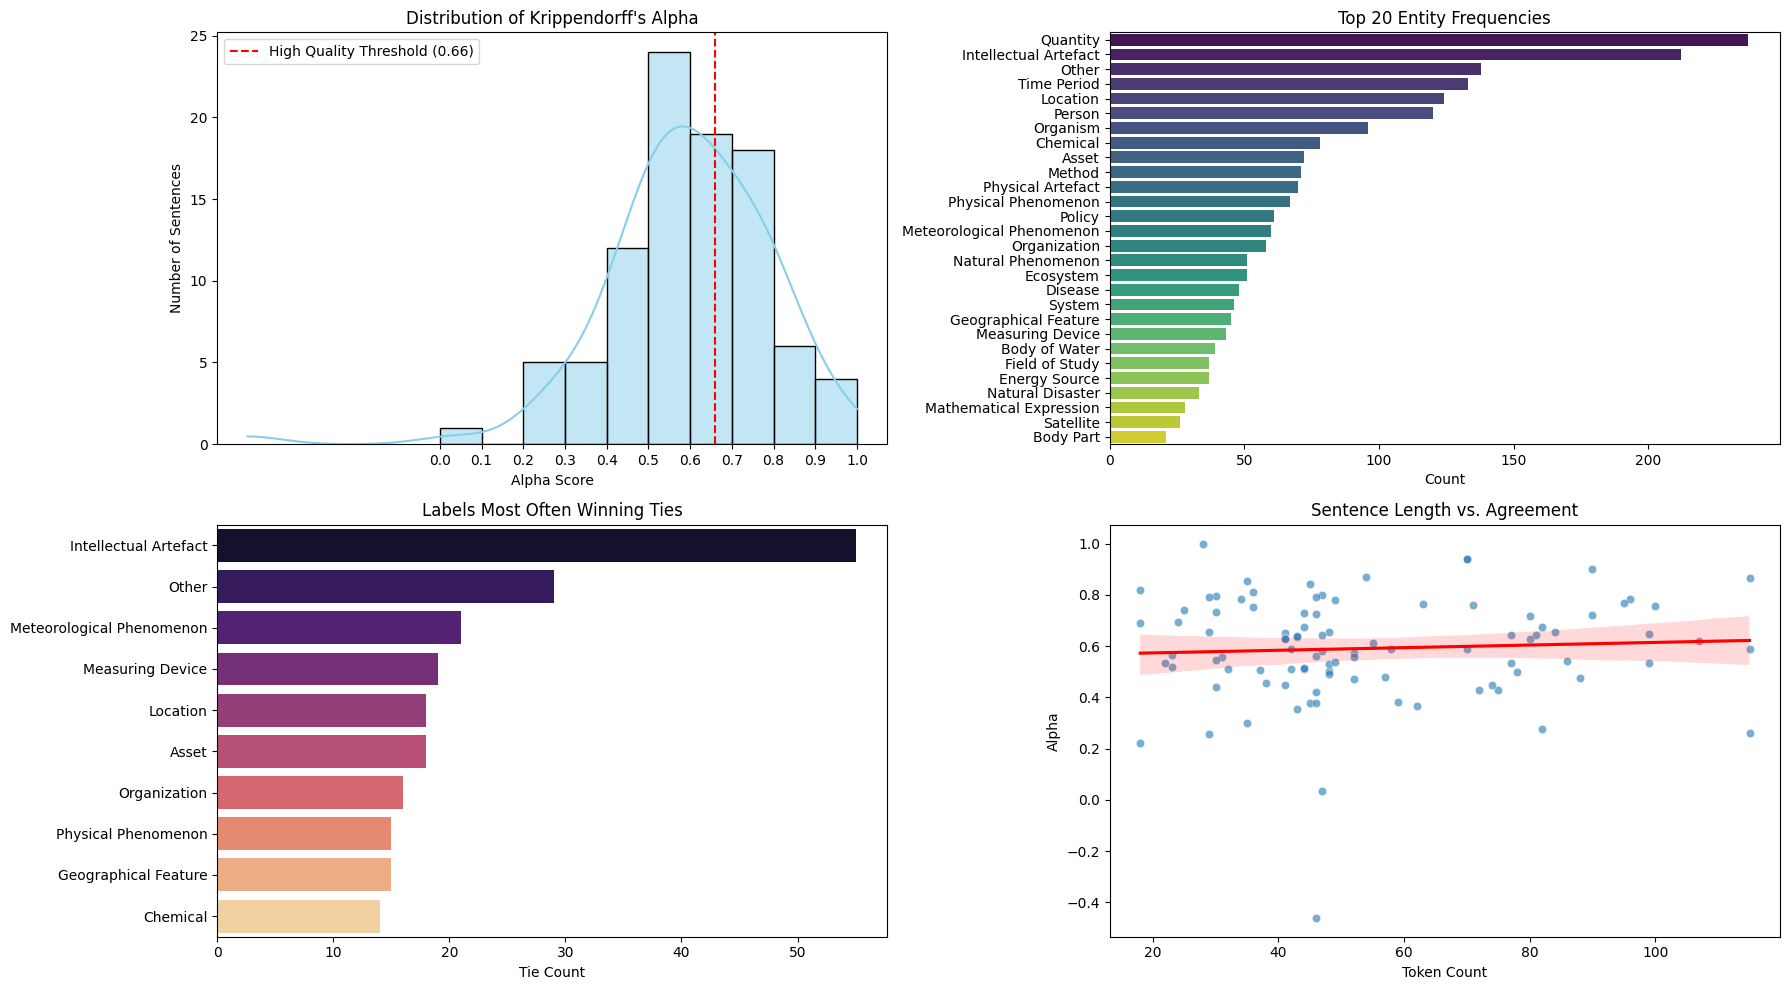

In [29]:
# --- Usage ---
analyze_consensus_statistics(consensus_data)